In [1]:
import numpy as np
import os
import glob
import scipy
import sys
import cv2
import math
import rawpy
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from scipy import fftpack
import torch.fft as fft
import matplotlib.pyplot as plt

In [2]:
iso_value = 25600
vmax = 0.0007; vmin=-vmax
dvmax = vmax * 0.5; dvmin = vmin * 0.5

In [3]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif', 'Times']
plt.rcParams['font.size'] = 16
plt.rcParams['pdf.fonttype'] = 42 
plt.rcParams['ps.fonttype'] = 42

# Functions

In [4]:
def pack_raw(raw, rescale=True):
    # pack Bayer image to 4 channels
    im = raw.raw_image_visible.astype(np.float32)
    im = np.maximum(im - 512, 0) # subtract the black level
    if rescale:
        im = im / (16383 - 512) 

    im = np.expand_dims(im, axis=2)
    img_shape = im.shape
    H = img_shape[0]
    W = img_shape[1]

    out = np.concatenate((im[0:H:2, 0:W:2, :], # r
                          im[0:H:2, 1:W:2, :], # g
                          im[1:H:2, 1:W:2, :], # b
                          im[1:H:2, 0:W:2, :]), axis=2) # g
    return out


def pack_np_raw(im):
    im = np.expand_dims(im, axis=2)
    img_shape = im.shape
    H = img_shape[0]
    W = img_shape[1]

    out = np.concatenate((im[0:H:2, 0:W:2, :], # r
                          im[0:H:2, 1:W:2, :], # g
                          im[1:H:2, 1:W:2, :], # b
                          im[1:H:2, 0:W:2, :]), axis=2) # g
    return out 
    

def histogram_1d(reference, sample, bin_min=-0.001, bin_max=0.001, bin_num=500, save_path=None):
    ref_hist, bins = np.histogram(reference.flatten(), bins=np.linspace(bin_min, bin_max, bin_num), density=True)
    samp_hist, _ = np.histogram(sample.flatten(), bins=bins, density=True)

    # Add small epsilon to avoid log(0)
    epsilon = 1e-10
    ref_hist += epsilon
    samp_hist += epsilon

    kl_div = np.sum(ref_hist * np.log(ref_hist / samp_hist)) * (bins[1] - bins[0])

    plt.figure()
    plt.hist(reference.flatten(), bins=np.linspace(bin_min, bin_max, bin_num), alpha=0.6, density=True, label='reference', color='#5aae61')
    plt.hist(sample.flatten(), bins=np.linspace(bin_min, bin_max, bin_num), alpha=0.6, density=True, label='synthetic', color='#9970ab')
    
    # plt.axvline(x=0, color='k', linestyle='--', linewidth=1)  # ← vertical line at x=0
    plt.legend()
    # plt.xticks(rotation=45)

    # plt.title(f"KLD: {kl_div:.3e}")
    
    # Hide ticks
    plt.xticks([])
    plt.yticks([])
    
    plt.text(0.01, 0.98, f"KLD: {kl_div:.3e}", transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=20)
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        
    plt.show()
    return kl_div


def quantify_numpy(image):
    image = 512 + (16383-512) * image
    image = np.clip(image, 0, 16383)
    image = np.round(image).astype(np.float32)
    image = (image-512) / (16383-512)
    return image


# Load a real noisy image

In [5]:
def get_files_per_iso(df,iso):
    """
    df is the panda dataframe which contains the metadata of the dataset
    iso is an int
    returns a list of pairs of gt and noisy image at some specific ISO
    """
    iso_string = "ISO"+str(iso)
    tmp = df[df["ISO"] == iso_string]
    pathes = tmp["path"].values
    pathes_long = tmp["path_long"].values
    pairs = []
    for i in range(len(pathes)):
        pairs.append((pathes[i],pathes_long[i]))
        
    return(pairs)


def read_raw_to_numpy(path):
    img = rawpy.imread(path)
    img = pack_raw(img, rescale=True)
    img = img.transpose(2,0,1)
    return img

In [6]:
path_csv = "/scratch/students/2023-fall-sp-liying/dataset/SID/Sony_train_list.txt"
df = pd.read_csv(path_csv,' ')
df.columns = ["path","path_long","ISO","Aperture"]
df["id"] = [p.split('/')[-1][:5] for p in df["path_long"].values]

/tmp/ipykernel_3896/83067452.py:2: FutureWarning: In a future version of pandas all arguments of read_csv except for the argument 'filepath_or_buffer' will be keyword-only.
  df = pd.read_csv(path_csv,' ')


In [7]:
pairs = get_files_per_iso(df, iso_value)
print(len(pairs))

92


In [8]:
noisy_path = os.path.join('/scratch/students/2023-fall-sp-liying/dataset/SID/', pairs[0][0])
real_noisy = read_raw_to_numpy(noisy_path)

In [9]:
real_noisy.shape

(4, 1424, 2128)

In [10]:
print(noisy_path)

/scratch/students/2023-fall-sp-liying/dataset/SID/./Sony/short/00195_00_0.033s.ARW


# Load a real dark frame

In [11]:
def load_darkframe(path):
    img_info = scipy.io.loadmat(path)
    img = img_info["Inoisy_crop"].astype(np.float32)
    img = (img - 512.) / (16383. - 512.)
    img = pack_np_raw(img)

    return img


def visualize(darkframe,vmin=None,vmax=None, use_colorbar=True, save_path=None):
    noise_vis = darkframe.copy()
    plt.figure(figsize = (10,5))

    noise_vis = noise_vis[...]
    if vmin is None and vmax is None:
        im = plt.imshow(noise_vis)
    else:
        im = plt.imshow(noise_vis, vmin = vmin,vmax = vmax)
    if use_colorbar:
        plt.colorbar(im, orientation='vertical')  # Adds color bar to the right
    plt.axis('off')
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.show()

In [12]:
data_path = sorted(glob.glob('/scratch/students/2023-fall-sp-liying/dataset/Sony_Bias_Frame/ISO%d/*_ISO%d.mat' % (iso_value, iso_value)))[0]
real_darkframe = load_darkframe(data_path)
real_darkframe = real_darkframe.transpose(2,0,1)

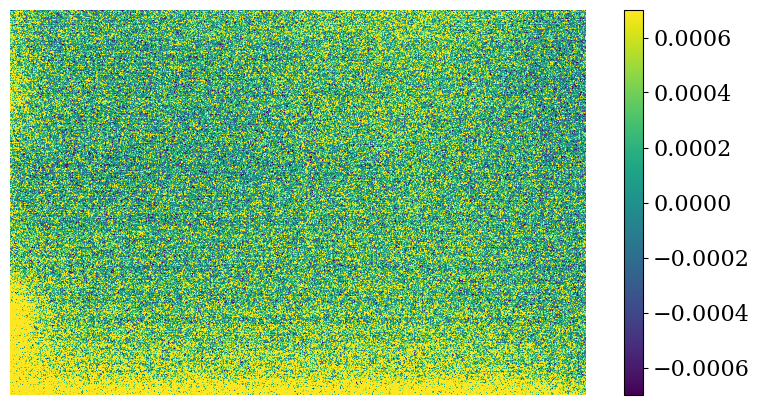

In [13]:
visualize(real_darkframe[0,:,:], vmin, vmax)

# Do the spectral sampling

In [14]:
def estimate_prior(img, darkshading):
    C, H, W = img.shape
    
    # Preprocess the image: img = (original - darkshading)
    img = img - darkshading

    m = torch.mean(img, dim=(-2, -1), keepdim=True)  # shape (4, 1, 1)
    
    img_zero_mean = img - m

    fft_img = torch.fft.fft2(img_zero_mean)
    
    return fft_img, m
    

def apply_gaussian_blur_torch(image, sigma=50):
    """
    Applies Gaussian blur to a PyTorch tensor image.
    
    Args:
        image: torch.Tensor of shape (C, H, W) or (B, C, H, W)
        sigma: float, standard deviation of the Gaussian kernel
    Returns:
        torch.Tensor of same shape as input, blurred
    """
    if image.ndim == 3:
        image = image.unsqueeze(0)
    
    B, C, H, W = image.shape
    device = image.device
    
    # Create 1D Gaussian kernel
    radius = int(3 * sigma)
    x = torch.arange(-radius, radius+1, device=device).float()
    kernel_1d = torch.exp(-0.5 * (x / sigma)**2)
    kernel_1d /= kernel_1d.sum()
    
    # Make 2D separable kernels
    kernel_x = kernel_1d.view(1, 1, 1, -1).repeat(C, 1, 1, 1)
    kernel_y = kernel_1d.view(1, 1, -1, 1).repeat(C, 1, 1, 1)
    
    # Pad and apply separable convolution
    padding = radius
    blurred = F.conv2d(F.pad(image, (padding, padding, 0, 0), mode='reflect'),
                       kernel_x, groups=C)
    blurred = F.conv2d(F.pad(blurred, (0, 0, padding, padding), mode='reflect'),
                       kernel_y, groups=C)
    
    if blurred.shape[0] == 1:
        blurred = blurred.squeeze(0)
    
    return blurred

    
def align_histogram_gpu(input, target):
    """
    GPU-accelerated histogram matching, channel-wise.
    
    Args:
        input: torch.Tensor, shape (C, H, W)
        target: torch.Tensor, shape (C, H, W)
    Returns:
        aligned: torch.Tensor, shape (C, H, W)
    """
    assert input.shape == target.shape, "input and target must have the same shape"
    C, H, W = input.shape
    device = input.device
    
    aligned = torch.empty_like(input)
    
    for c in range(C):
        # Flatten
        s_flat = input[c].reshape(-1)
        t_flat = target[c].reshape(-1)
        
        # Sort both
        s_sorted, s_indices = torch.sort(s_flat)
        t_sorted = torch.sort(t_flat)[0]
        
        # Create inverse mapping: for each position in original, 
        # find its rank, then map to target's sorted value at that rank
        # This is equivalent to: aligned[original_indices] = target_sorted
        inverse_indices = torch.argsort(s_indices)
        aligned[c] = t_sorted[inverse_indices].reshape(H, W)
    
    return aligned

    
def align_histogram_gpu_batched(input, target):
    """
    Faster GPU histogram matching using batched operations.
    Works when all channels can be processed together.
    
    Args:
        input: torch.Tensor, shape (C, H, W)
        target: torch.Tensor, shape (C, H, W)
    Returns:
        aligned: torch.Tensor, shape (C, H, W)
    """
    C, H, W = input.shape
    device = input.device
    N = H * W
    
    # Reshape to (C, N)
    input_flat = input.reshape(C, N)
    target_flat = target.reshape(C, N)
    
    # Sort along spatial dimension for each channel
    input_sorted, input_indices = torch.sort(input_flat, dim=1)
    target_sorted = torch.sort(target_flat, dim=1)[0]
    
    # Inverse indices for scatter
    inverse_indices = torch.argsort(input_indices, dim=1)
    
    # Gather target values according to ranking
    aligned_flat = torch.gather(target_sorted, 1, inverse_indices)
    
    return aligned_flat.reshape(C, H, W)

def iterative_histogram_spectral_matching(
    fft_reference, 
    darkshading, 
    reference_residual,
    num_iterations=3,
    device='cuda',
    use_batched=False
):
    """
    Iteratively refine noise sample by alternating between:
    1. Histogram matching (preserves all moments)
    2. Spectral constraint (preserves spatial correlations)
    
    Args:
        fft_reference: FFT of reference residual (reference - darkshading)
        darkshading: Fixed pattern noise estimate
        reference_residual: Reference residual in spatial domain (for histogram target)
        num_iterations: Number of refinement iterations
        device: torch device
        use_batched: Use faster batched histogram matching
        
    Returns:
        sample: Refined noise sample with both correct distribution and spectrum
    """
    C, H, W = darkshading.shape
    
    # Initial synthesis
    white_noise = torch.randn(H, W, device=device)
    white_noise = white_noise.unsqueeze(0).expand(C, -1, -1)
    # ------------ without channel correlation ----------
    # white_noise = torch.randn(C, H, W, device=device)
    # -------------------------
    
    
    fft_white = torch.fft.fft2(white_noise)
    
    # --------- ADSN (has the similar performance ------
    # out_fft = fft_reference * fft_white
    # norm_factor = np.sqrt(H * W)
    # sample = torch.fft.ifft2(out_fft).real / norm_factor
    # -------------------------

    magnitude_ref = torch.abs(fft_reference)
    phase_ref = torch.angle(fft_reference)
    magnitude_white = torch.abs(fft_white)
    phase_white = torch.angle(fft_white)
    sample_fft = magnitude_ref * torch.exp(1j * (phase_ref + phase_white))
    sample = torch.fft.ifft2(sample_fft).real

    align_fn = align_histogram_gpu_batched if use_batched else align_histogram_gpu
    
    # Iterative refinement
    for i in range(num_iterations):
        # Step 1: Histogram matching (preserves distribution)
        sample = align_fn(sample, reference_residual)
        
        # Step 2: Re-impose spectral constraint
        sample_mean = sample.mean(dim=(1, 2), keepdim=True)
        sample_centered = sample - sample_mean
        sample_fft = torch.fft.fft2(sample_centered)
        
        # Replace magnitude with reference, keep current phase
        magnitude_ref = torch.abs(fft_reference)
        phase_current = torch.angle(sample_fft)
        
        # Reconstruct with reference magnitude and current phase
        sample_fft_corrected = magnitude_ref * torch.exp(1j * phase_current)
        
        # Transform back
        sample = torch.fft.ifft2(sample_fft_corrected).real + sample_mean
    
    # Add back the fixed pattern
    sample = sample + darkshading
    
    return sample


def synthesize_darkframe_improved(reference, num_iterations=3, device='cuda'):
    """
    Improved method with iterative histogram-spectral matching.
    Fully GPU-accelerated!
    
    Args:
        reference: numpy array or torch tensor of shape (C, H, W)
        num_iterations: Number of refinement iterations
        device: torch device
        
    Returns:
        sample: numpy array of shape (C, H, W)
    """
    # Convert to torch if needed
    if isinstance(reference, np.ndarray):
        reference = torch.from_numpy(reference).float().to(device)
    else:
        reference = reference.to(device)
    
    darkshading = apply_gaussian_blur_torch(reference, sigma=50)
    reference_residual = reference - darkshading
    fft_reference, global_mean = estimate_prior(reference, darkshading)
    
    sample = iterative_histogram_spectral_matching(
        fft_reference=fft_reference,
        darkshading=darkshading,
        reference_residual=reference_residual,
        num_iterations=num_iterations,
        device=device,
        use_batched=False  
    )

    sample += global_mean
    
    return sample.cpu().numpy(), darkshading.cpu().numpy()


# Example usage:
# real_darkframe: numpy array of shape (C, H, W)
# sample_aligned = synthesize_darkframe_improved(real_darkframe, num_iterations=3)

In [15]:
num_iter = 10
sample_aligned, darkshading = synthesize_darkframe_improved(
    real_darkframe,  # Can be numpy or torch tensor
    num_iterations=num_iter,
    device='cuda'
)

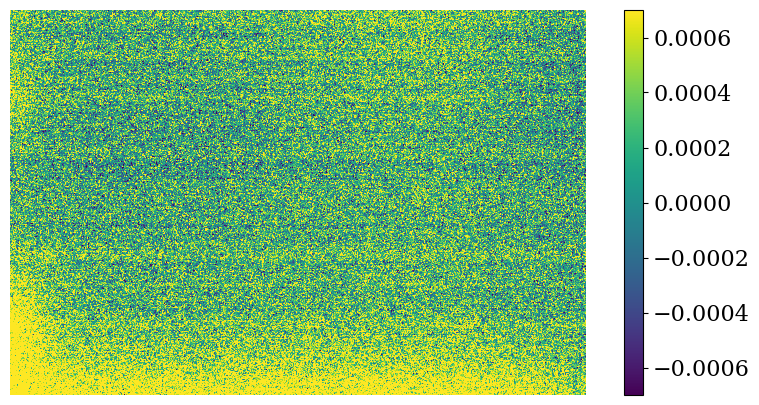

In [16]:
visualize(sample_aligned[0,:,:], vmin, vmax, use_colorbar=True, save_path=None)

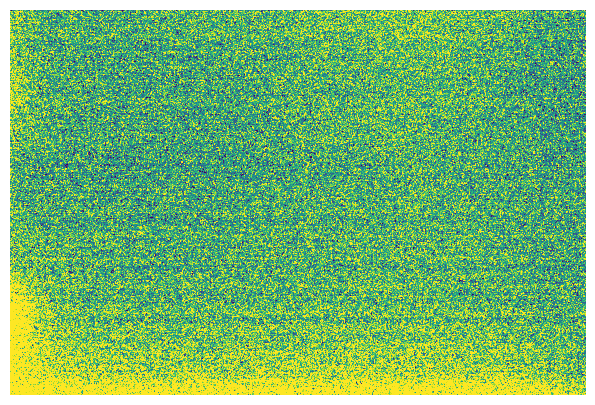

In [17]:
visualize(real_darkframe[0,:,:], vmin, vmax, use_colorbar=False, save_path=None)

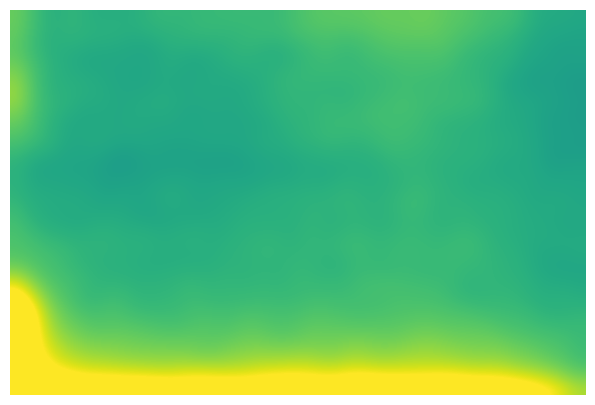

In [18]:
visualize(darkshading[0,:,:], vmin, vmax, use_colorbar=False)

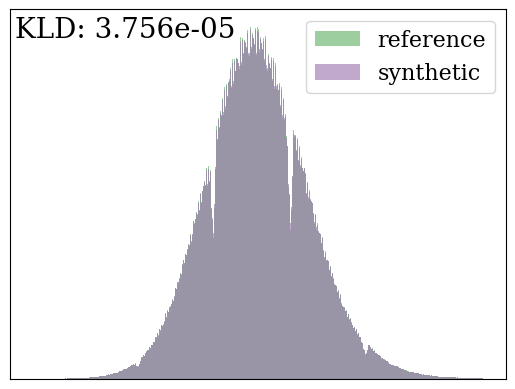

3.756263611135964e-05

In [19]:
histogram_1d(real_darkframe-darkshading, (sample_aligned)-darkshading, bin_min=-0.007, bin_max=0.007, save_path=None)

# Generate multiple dark frames per ISO (in the value range of [0,1] and with adding darkshading back)

In [13]:
def batch_synthesize_darkframes(
    iso_list,
    num_per_iso=400,
    num_iterations=3,
    device='cuda',
    save_folder='SampledDarkFrames',
    save_folder_ds='SampledDarkShadings',
    data_path_template='/scratch/students/2023-fall-sp-liying/dataset/Sony_Bias_Frame/ISO%d/*.mat',
    batch_size=10  # Synthesize multiple samples before saving
):
    """
    Batch synthesize dark frames for multiple ISO settings with improved method.
    
    Args:
        iso_list: List of ISO values to process
        num_per_iso: Number of samples to generate per ISO
        num_iterations: Number of histogram-spectral refinement iterations
        device: torch device
        save_folder: Folder to save synthesized dark frames
        save_folder_ds: Folder to save dark shadings
        data_path_template: Path template for loading reference dark frames
        batch_size: Number of samples to synthesize before saving (reduces I/O)
    """
    os.makedirs(save_folder, exist_ok=True)
    os.makedirs(save_folder_ds, exist_ok=True)
    
    total_steps = len(iso_list) * (1 + num_per_iso)  # 1 for loading/processing, num_per_iso for synthesis
    
    with tqdm(total=total_steps, desc="Synthesizing dark frames") as pbar:
        for iso_value in iso_list:
            # Load reference dark frame
            data_path = sorted(glob.glob(data_path_template % iso_value))[0]
            real_darkframe = load_darkframe(data_path)
            real_darkframe = real_darkframe.transpose(2, 0, 1)  # (H, W, C) -> (C, H, W)
            
            # Convert to torch once
            reference = torch.from_numpy(real_darkframe).float().to(device)
            
            # Compute and save dark shading (only once per ISO)
            darkshading = apply_gaussian_blur_torch(reference, sigma=50)
            darkshading_np = darkshading.cpu().numpy()
            
            save_name_ds = os.path.join(save_folder_ds, f'ISO{iso_value}.npy')
            np.save(save_name_ds, darkshading_np)
            
            # Prepare for synthesis
            reference_residual = reference - darkshading
            global_mean = reference_residual.mean(dim=(1,2), keepdim=True)
            reference_residual = reference_residual - global_mean
            fft_reference = torch.fft.fft2(reference_residual)

            pbar.set_description(f"Processing ISO {iso_value}")
            pbar.update(1)
            
            # Generate multiple dark frames in batches
            for batch_start in range(0, num_per_iso, batch_size):
                batch_end = min(batch_start + batch_size, num_per_iso)
                current_batch_size = batch_end - batch_start
                
                # Synthesize batch
                samples_batch = []
                for i in range(current_batch_size):
                    sample = iterative_histogram_spectral_matching(
                        fft_reference=fft_reference,
                        darkshading=darkshading,
                        reference_residual=reference_residual,
                        num_iterations=num_iterations,
                        device=device,
                        use_batched=False
                    )
                    sample = sample + global_mean
                    
                    samples_batch.append(sample.cpu().numpy())
                
                # Save batch
                for i, sample_np in enumerate(samples_batch):
                    save_idx = batch_start + i
                    save_name = os.path.join(save_folder, f'ISO{iso_value}_{save_idx:05d}.npy')
                    np.save(save_name, sample_np)
                    pbar.update(1)
            
            # Clear GPU cache after each ISO to prevent memory buildup
            del reference, darkshading, reference_residual, fft_reference
            if device == 'cuda':
                torch.cuda.empty_cache()


In [16]:
iso_list = [25600, 6400, 800, 4000, 3200, 64, 20000, 500, 1600, 80, 125, 2000, 8000, 640, 5000, 10000, 12800, 16000, 2500, 1000, 1250, 400, 320, 250, 100, 50, 160, 200]
num_per_iso=400
num_iterations=10
device='cuda'
save_folder='SampledDarkFrames'
save_folder_ds='SampledDarkShadings'
data_path_template='/scratch/students/2023-fall-sp-liying/dataset/Sony_Bias_Frame/ISO%d/*.mat'
batch_size=10  # Synthesize multiple samples before saving
batch_synthesize_darkframes(iso_list, num_per_iso, num_iterations, device, save_folder, save_folder_ds, data_path_template, batch_size)

Synthesizing dark frames:   0%|          | 0/303 [00:00<?, ?it/s]
